# Tutorial 12 — From raw data to a recommendation

## 1. Problem / context

This notebook is a **template for the project and the oral exam**. We take the thickness data, describe it, notice possible structure (two lines, late samples), choose methods from earlier sessions, and write a recommendation a production engineer could use.

We do not introduce new models.

## 2. Core theory

Method choice (see also Session 12):

- Numeric response, no predictor, one target value → CI / one-sample test.
- Two groups → two-sample or paired $t$.
- Three or more groups → ANOVA.
- Numeric predictor → simple linear regression.
- Categories → chi-square.

Always start with Session 01 plots. Always end with assumptions, limitations, and uncertainty.

The column `shift_um` documents a planted late drift. In a real project you would not be handed the truth; you would have to **discover** drift from time order (`sample_id`).

## 3. From mathematics to Python

Reuse the libraries from previous tutorials. Keep the narrative in markdown cells.

## 4. Python implementation


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import ttest_1samp, ttest_ind, t

candidates = [Path("data"), Path("../data")]
DATA = next(p for p in candidates if p.exists())
df = pd.read_csv(DATA / "sensor_thickness.csv")
df.head()


,sample_id,line,thickness_um,shift_um
0,1,A,246.669,0.0
1,2,A,251.010,0.0
2,3,A,242.035,0.0
3,4,A,255.862,0.0
4,5,A,252.681,0.0


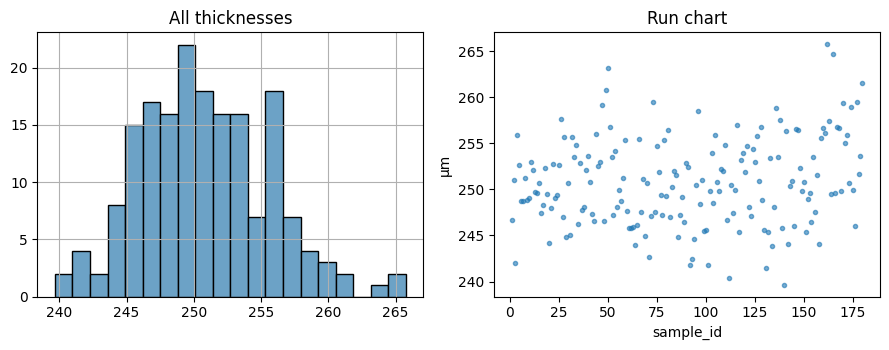

      count        mean       std      min        25%       50%       75%  \
line                                                                        
A      90.0  250.422144  4.161238  242.035  247.28625  249.6860  252.8675   
B      90.0  251.238567  5.372533  239.668  247.45050  250.8615  255.4375   

          max  
line           
A     263.234  
B     265.756  


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
df["thickness_um"].hist(bins=20, ax=axes[0], color="#6CA2C6", edgecolor="black")
axes[0].set_title("All thicknesses")
axes[1].plot(df["sample_id"], df["thickness_um"], ".", alpha=0.6)
axes[1].set_xlabel("sample_id")
axes[1].set_ylabel("µm")
axes[1].set_title("Run chart")
plt.tight_layout()
plt.show()

print(df.groupby("line")["thickness_um"].describe())


In [3]:
# One-sample: overall mean versus 250 µm
x = df["thickness_um"]
print("vs 250:", ttest_1samp(x, 250.0))

# Two lines
a = df.loc[df["line"] == "A", "thickness_um"]
b = df.loc[df["line"] == "B", "thickness_um"]
print("A vs B Welch:", ttest_ind(a, b, equal_var=False))


vs 250: TtestResult(statistic=np.float64(2.3164656779472375), pvalue=np.float64(0.021665582029369343), df=np.int64(179))
A vs B Welch: TtestResult(statistic=np.float64(-1.1397485447439941), pvalue=np.float64(0.25601805959304147), df=np.float64(167.5239445287688))


In [4]:
early = df.loc[df["sample_id"] <= 155, "thickness_um"]
late = df.loc[df["sample_id"] > 155, "thickness_um"]
print("early vs late:", ttest_ind(early, late, equal_var=False))
print("late mean", late.mean(), "early mean", early.mean())


early vs late: TtestResult(statistic=np.float64(-3.7356055052569115), pvalue=np.float64(0.0008107500352281089), df=np.float64(29.165699958295722))
late mean 254.56040000000002 early mean 250.22873548387096


## 5. Interpretation

A complete write-up would now:

1. State the question (on-target mean? line effect? drift?).
2. Justify each test and its assumptions.
3. Report estimates, intervals, and $p$-values.
4. Recommend an action (investigate late samples / do not retarget the mean / compare lines with a designed experiment).

The run chart is essential: a two-sample test of lines can be misleading if the real issue is **time order**.

## 6. Common mistakes / things to notice

- Running every test in the course on the same data without a question (“p-hacking”).
- Hiding a run chart and only reporting a global $t$-test.
- Delivering Python output with no recommendation.

## 7. Short worked example

Write the oral-exam paragraph (example structure):

> We asked whether mean thickness matches 250 µm and whether lines A and B differ. Descriptive plots show a compact distribution and a possible rise in later sample IDs. A one-sample $t$-test addresses the target; a Welch test compares lines. Because later IDs look shifted, we also compared early versus late samples. Any recommendation to retarget the process should wait until the late-sample drift is understood; otherwise we would be fitting a mean that is a mixture of two regimes.

**Conclusion in one sentence:** A project-quality analysis starts with a question and a picture, chooses one or two methods on purpose, reports uncertainty, and ends with an engineering recommendation — that is also what the oral exam is looking for.
